# Physics-Informed Machine Learning
## Notebook 04 — Our First Physics-Informed Neural Network

### Problem

We want to solve:

    dy/dt = 2y

with the initial condition:

    y(0) = 1

We already know the analytical solution:

    y(t) = e^(2t)

But we will NOT give this solution to the neural network during training.

Instead, the neural network will learn a function:

    y_hat(t)

and we will require that:

    dy_hat/dt - 2y_hat = 0

while also requiring:

    y_hat(0) = 1

This is a Physics-Informed Neural Network (PINN).

# 1. The Main Idea

A normal neural network learns from labeled examples.

For example:

    t → y_true

and minimizes:

    Data Loss = MSE(y_hat, y_true)

A PINN can work differently.

We know the governing differential equation:

    dy/dt = 2y

So if the network predicts:

    y_hat(t)

we can calculate:

    dy_hat/dt

using automatic differentiation.

Then define the differential equation residual:

    R(t) = dy_hat/dt - 2y_hat

For a correct solution:

    R(t) = 0

Therefore the physics loss is:

    L_physics = mean(R(t)^2)

We also need the initial condition:

    y_hat(0) = 1

so:

    L_initial = (y_hat(0) - 1)^2

Finally:

    L_total = L_physics + L_initial

The neural network is trained to minimize this loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)

PyTorch: 2.13.0+cpu


# 2. Neural Network

The network receives:

    t

and outputs:

    y_hat(t)

Architecture:

    t
    ↓
    Linear
    ↓
    Tanh
    ↓
    Linear
    ↓
    Tanh
    ↓
    Linear
    ↓
    y_hat

In [2]:
class PINN(nn.Module):
    """
    Neural network representing the unknown function y(t).

    Input:
        t

    Output:
        y_hat(t)
    """

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.network(t)


model = PINN()

print(model)

PINN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 3. Collocation Points

Here is an important PINN concept.

We do not necessarily need a dataset containing:

    t → y

Instead, we choose points in the domain where we want the differential
equation to be satisfied.

These are called:

    collocation points

For example:

    t = 0.0
    t = 0.1
    t = 0.2
    ...
    t = 2.0

At every point, we ask:

    Does the neural network satisfy the ODE here?

We therefore need:

    t.requires_grad_(True)

because PyTorch must calculate:

    dy_hat/dt

In [3]:
# Domain of the problem
t_min = 0.0
t_max = 2.0

# Number of collocation points
N = 1000

# Create collocation points
t_collocation = torch.linspace(
    t_min,
    t_max,
    N
).reshape(-1, 1)

# We need derivatives with respect to t
t_collocation.requires_grad_(True)

print("Shape:", t_collocation.shape)
print("First points:")
print(t_collocation[:5])

Shape: torch.Size([1000, 1])
First points:
tensor([[0.0000],
        [0.0020],
        [0.0040],
        [0.0060],
        [0.0080]], grad_fn=<SliceBackward0>)


# 4. Automatic Differentiation

The network gives us:

    y_hat = NN(t)

We now need:

    dy_hat/dt

PyTorch's autograd can calculate this.

The important sequence is:

    t
    ↓
    Neural Network
    ↓
    y_hat
    ↓
    autograd
    ↓
    dy_hat/dt

In [4]:
def model_derivative(model, t):
    """
    Calculate dy_hat/dt using PyTorch automatic differentiation.
    """

    y_hat = model(t)

    dy_dt = torch.autograd.grad(
        outputs=y_hat,
        inputs=t,
        grad_outputs=torch.ones_like(y_hat),
        create_graph=True
    )[0]

    return y_hat, dy_dt

# 5. Physics Residual

Our differential equation is:

    dy/dt = 2y

The neural network produces:

    y_hat

and:

    dy_hat/dt

Therefore:

    R(t) = dy_hat/dt - 2y_hat

A perfect solution gives:

    R(t) = 0

So our physics loss is:

    L_physics = mean(R(t)^2)

In [5]:
def physics_residual(model, t):
    """
    Calculate the residual of:

        dy/dt = 2y

    Residual:

        R = dy/dt - 2y
    """

    y_hat, dy_dt = model_derivative(model, t)

    residual = dy_dt - 2 * y_hat

    return residual

# 6. Initial Condition

Our ODE alone is not enough.

We also know:

    y(0) = 1

Therefore the neural network must satisfy:

    y_hat(0) = 1

The initial-condition loss is:

    L_initial = (y_hat(0) - 1)^2

In [6]:
def initial_condition_loss(model):
    """
    Calculate the loss associated with:

        y(0) = 1
    """

    t0 = torch.tensor([[0.0]])

    y0_pred = model(t0)

    target = torch.tensor([[1.0]])

    loss = (y0_pred - target) ** 2

    return loss.mean()

# 7. Total Loss

We now have two objectives.

### Physics

Make the network obey:

    dy/dt = 2y

### Initial condition

Make the network satisfy:

    y(0) = 1

Therefore:

    L_total =
        L_physics
        +
        L_initial

This is the central loss function of our first PINN.

In [8]:
def pinn_loss(model, t):
    """
    Calculate the total PINN loss.

    Total loss:

        L = L_physics + L_initial
    """

    # Physics residual
    residual = physics_residual(model, t)

    physics_loss = torch.mean(residual ** 2)

    # Initial condition loss
    initial_loss = initial_condition_loss(model)

    total_loss = physics_loss + initial_loss

    return total_loss, physics_loss, initial_loss

In [9]:
total_loss, physics_loss, initial_loss = pinn_loss(
    model,
    t_collocation
)

print("Initial total loss :", total_loss.item())
print("Initial physics loss:", physics_loss.item())
print("Initial condition loss:", initial_loss.item())

Initial total loss : 1.3594696521759033
Initial physics loss: 0.18850210309028625
Initial condition loss: 1.1709675788879395


# 8. Before Training

The neural network currently contains randomly initialized parameters.

Therefore it probably produces a function that does NOT satisfy:

    dy/dt = 2y

and probably does NOT satisfy:

    y(0) = 1

Training will modify the network parameters until both requirements
are approximately satisfied.

In [10]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5000

total_history = []
physics_history = []
initial_history = []

for epoch in range(epochs):

    # Calculate losses
    total_loss, physics_loss, initial_loss = pinn_loss(
        model,
        t_collocation
    )

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    total_loss.backward()

    # Update neural network parameters
    optimizer.step()

    # Store losses
    total_history.append(total_loss.item())
    physics_history.append(physics_loss.item())
    initial_history.append(initial_loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.item():.8f} | "
            f"Physics: {physics_loss.item():.8f} | "
            f"Initial: {initial_loss.item():.8f}"
        )

Epoch    0 | Total: 1.35946965 | Physics: 0.18850210 | Initial: 1.17096758
Epoch  500 | Total: 0.66654134 | Physics: 0.22189911 | Initial: 0.44464222
Epoch 1000 | Total: 0.66604221 | Physics: 0.22203329 | Initial: 0.44400892
Epoch 1500 | Total: 0.66532063 | Physics: 0.22203501 | Initial: 0.44328564
Epoch 2000 | Total: 0.66394830 | Physics: 0.22189817 | Initial: 0.44205016
Epoch 2500 | Total: 0.65880287 | Physics: 0.22152436 | Initial: 0.43727851
Epoch 3000 | Total: 0.64131433 | Physics: 0.21468328 | Initial: 0.42663103
Epoch 3500 | Total: 0.62032771 | Physics: 0.21215107 | Initial: 0.40817666
Epoch 4000 | Total: 0.59389389 | Physics: 0.20301822 | Initial: 0.39087567
Epoch 4500 | Total: 0.55328190 | Physics: 0.18925713 | Initial: 0.36402479


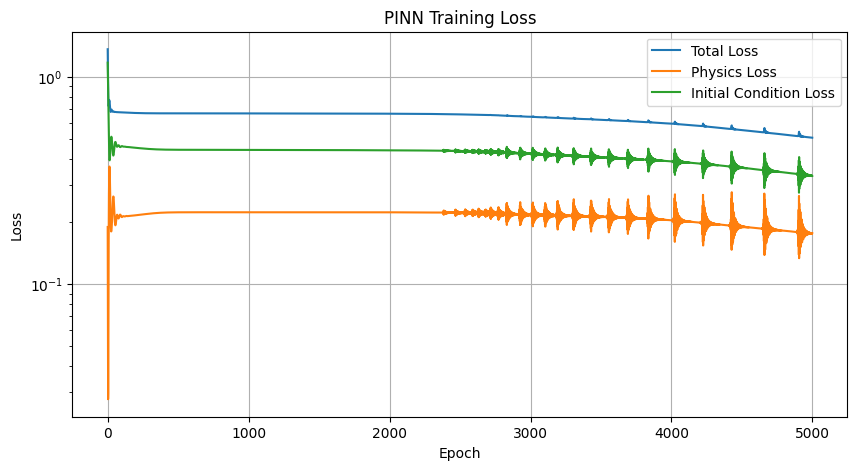

In [11]:
plt.figure(figsize=(10, 5))

plt.semilogy(
    total_history,
    label="Total Loss"
)

plt.semilogy(
    physics_history,
    label="Physics Loss"
)

plt.semilogy(
    initial_history,
    label="Initial Condition Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.grid(True)
plt.legend()

plt.show()

# 9. Evaluate the Learned Solution

Our PINN has now learned a function:

    y_hat(t)

We can compare it with the analytical solution:

    y(t) = e^(2t)

Remember:

The analytical solution was NOT used during training.

It is being used only now to evaluate the quality of the PINN.

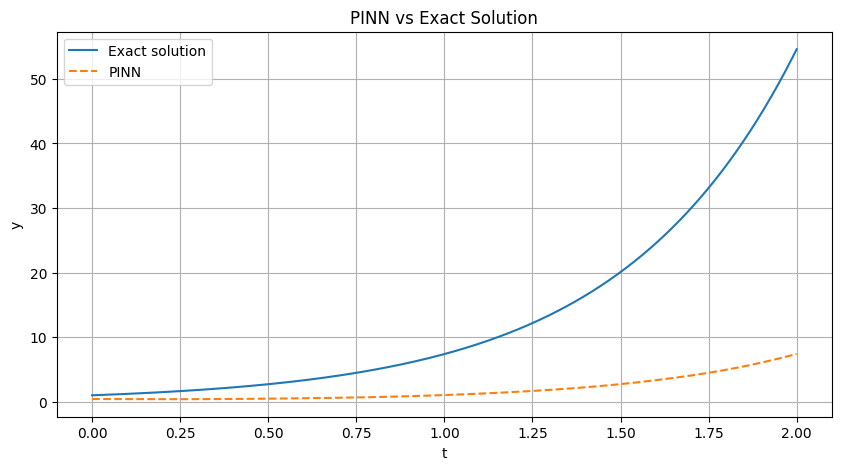

In [12]:
# Evaluation points
t_test = torch.linspace(
    0,
    2,
    500
).reshape(-1, 1)

with torch.no_grad():
    y_pinn = model(t_test)

y_pinn = y_pinn.numpy().flatten()

t_test_np = t_test.numpy().flatten()

# Exact solution
y_exact = np.exp(2 * t_test_np)

plt.figure(figsize=(10, 5))

plt.plot(
    t_test_np,
    y_exact,
    label="Exact solution"
)

plt.plot(
    t_test_np,
    y_pinn,
    "--",
    label="PINN"
)

plt.xlabel("t")
plt.ylabel("y")
plt.title("PINN vs Exact Solution")
plt.grid(True)
plt.legend()

plt.show()